# Rigid Termination Plucked String WaveGuide Implementation 

In this Exercise we will implement an elementary waveguide simulation of plucked strings with rigid termination (nut and bridge). 

This is a baseline python class implementation inspired by the design of Julius O Smith: https://ccrma.stanford.edu/~jos/pmudw/pmudw.pdf


 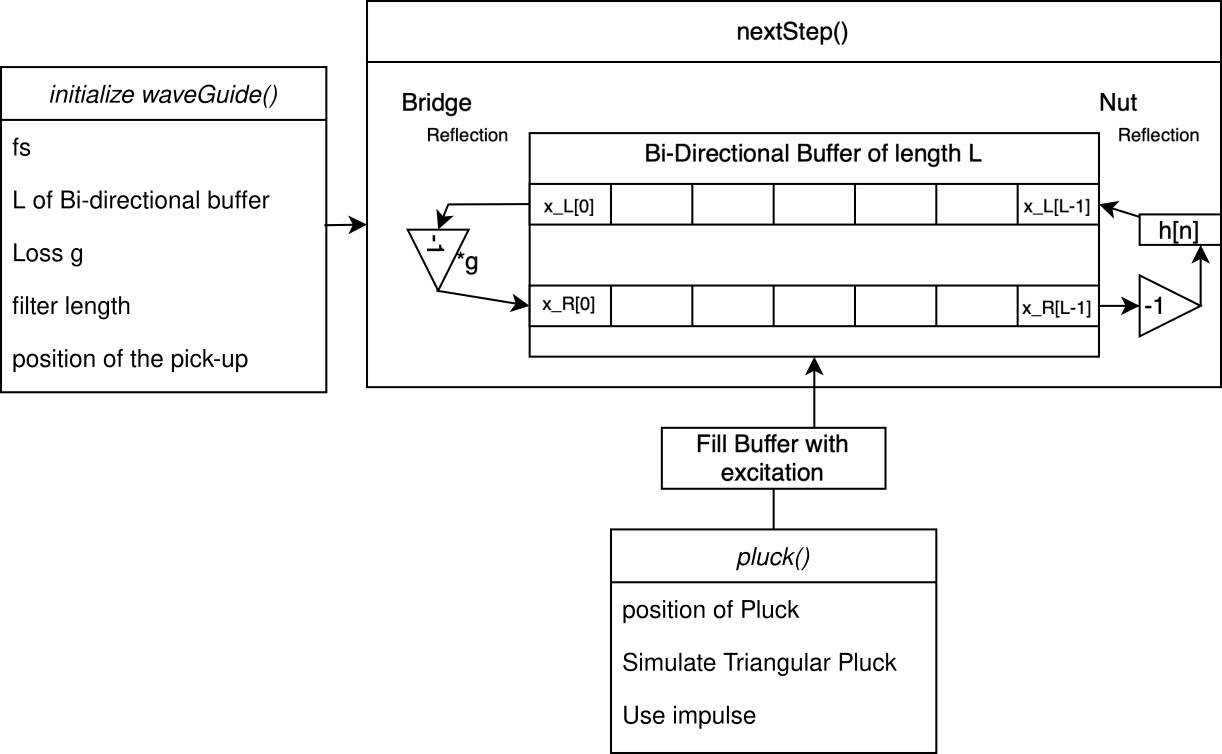

### Import Statements

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import IPython.display as ipd
from scipy import signal
from scipy.io import wavfile

## Digital Waveguide Class

In [4]:
class waveGuide:
    
    def __init__(self, L, pickup_position, loss_factor=0.995, filter_size=6):

        # Constructor to initialize the waveguide object

        self.fs  =  48000
        
        # set length
        self.L   =  L

        # Ensure the pick_up position is within bounds
        self.pickup_position = max(1, min(pickup_position, self.L-2))

        # Initialize loss
        self.g = loss_factor

        #Initialize filter
        self.filter_size = filter_size

        # Initialize buffers
        self.x_L = '[CODE]'
        self.x_R = '[CODE]'

        self.filter = np.zeros(self.filter_size)
    

    def pluck(self, position):

        # Method to simulate a string pluck as a triangular wave

        position = max(1, min(position, self.L-2))
        
        # Reset filter buffer
        self.filt = np.zeros(self.filter_size)
        
        # standard triangular pluck shape

        #Reset the buffers
        self.x_L = np.zeros(self.L)
        self.x_R = np.zeros(self.L)

        # Create a triangular wave
        # Rising slope
        self.x_L[1:position+1] = '[CODE]'
        self.x_R[1:position+1] = '[CODE]'
            
        # Falling slope
        self.x_L[position:self.L-1] = '[CODE]'
        self.x_R[position:self.L-1] = '[CODE]'

    

    def nextStep(self):

         # Method to simulate the wave propogation
           
            # Get samples at boundaries
            l_out = '[CODE]'          # Sample at the bridge (left end)
            r_out = '[CODE]'  # Sample at the nut (right end)
            
            # Calculate filter output (moving average)
            f_out = np.mean(self.filt)
            

            # Shift the values in the delay line to simulate the wave propogation
            self.x_L = '[CODE]' #shift left 
            self.x_R = '[CODE]' #shift right

            # The values in the filter are shifted too 
            self.filt = np.roll(self.filt, 1) 
            

            # Reflection at the bridge
            self.x_L[self.L-1] = '[CODE]'  

            # Reflection at the nut
            self.x_R[0] = '[CODE]'

            # Fill the filter 
            self.filt[0] = r_out                    
            
            
            # Read the output of the bi-directional buffer at the pickup_position
        
            out = '[CODE]'
            
            return out
        
        
        
        
        

## Method to Simulate the Wave using the waveGuide class

In [7]:
def simulateWave(duration, L, pickup_position, pluck_position, loss_factor,filter_length):
    '''
    duration: How long is the signal
    L: Length of string
    pickup_position: where is the pickup located
    pluck_position: where are you plucking the string 
    loss_factor: Damping factor
    filter_length: Lenght of the Filter (frequency dependent damping)
    '''

    # Initialize waveGuide
    waveguide = waveGuide(L, pickup_position,loss_factor,filter_length)
    
    # Initialize output
    output = np.zeros(duration*waveguide.fs)

    # Initialize the buffers with the triangular pluck
    waveguide.pluck(pluck_position)

    # Fill the output buffer
    '[CODE]'

    output = output/np.max(np.abs(output))
    
    return output
    
    

In [8]:
## TEST CODE
#out = simulateWave(3,300, 5,7,0.99, 20,)
#audio = ipd.Audio(out, rate=48000)
#plt.plot(out)
#display(audio)